# Visual Analytics

## Assignment 3

**Instructor:** Dr. Marco D'Ambros  
**TAs:** Giuseppe Crupi, Mattia Giannaccari

**Contacts:** marco.dambros@usi.ch, giuseppe.crupi@usi.ch, mattia.giannaccari@usi.ch

**Due Date:** May 25, 2026 @ 23:55

---
The goal of this assignment is to use **Spark (PySpark)** and **Polars** in Jupyter notebooks.  
The files `trip_data.csv`, `trip_fare.csv`, and `nyc_boroughs.geojson` are available in the provided folder: [Assignment3-data](https://usi365-my.sharepoint.com/:f:/g/personal/armenc_usi_ch/Ejp7sb8QAMROoWe0XUDcAkMBoqUFk-w2Vgroup025NhAww?e=2I7SMC).

- Use **Spark** to solve **Exercises 1–4**
- Use **Polars** to solve **Exercises 5–8**

Please name your notebook file as `SurnameName_Assignment3.ipynb`

# ⚡️ Spark Exercises (50 pts)

### Importing the libraries

In [1]:
import os
import json

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import StringType
from pyspark.sql import Window

from shapely.geometry import shape, Point

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, FactorRange, Legend, LegendItem
from bokeh.transform import factor_cmap
from bokeh.palettes import Spectral4

### Initial Spark Setup

In [2]:
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = "python"

spark = SparkSession.builder \
    .appName("Assignment3") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

spark.range(5).show()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/26 17:25:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



### Importing and cleaning the data

In [3]:
# Loading the datasets
# After selecting the dataset thanks to the related paths, header=True is used to consider the first row as column names while 
# inferSchema=True is used to automatically detect data types

trip_data = spark.read.csv(
    "data-assignment3/trip_data.csv", header=True, inferSchema=True
)

trip_fare = spark.read.csv(
    "data-assignment3/trip_fare.csv", header=True, inferSchema=True
)

# Since the column names have spaces, they need to be trimmed before joining
trip_data = trip_data.toDF(*[c.strip() for c in trip_data.columns])
trip_fare = trip_fare.toDF(*[c.strip() for c in trip_fare.columns])

# Visualizing the clean datasets without spaces in column names
trip_data.show(5)
trip_fare.show(5)

+--------------------+--------------------+---------+---------+------------------+-------------------+-------------------+---------------+-----------------+-------------+----------------+---------------+-----------------+----------------+
|           medallion|        hack_license|vendor_id|rate_code|store_and_fwd_flag|    pickup_datetime|   dropoff_datetime|passenger_count|trip_time_in_secs|trip_distance|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|
+--------------------+--------------------+---------+---------+------------------+-------------------+-------------------+---------------+-----------------+-------------+----------------+---------------+-----------------+----------------+
|89D227B655E5C82AE...|BA96DE419E711691B...|      CMT|        1|                 N|2013-01-01 15:11:48|2013-01-01 15:18:10|              4|              382|          1.0|      -73.978165|      40.757977|       -73.989838|       40.751171|
|0BD7C8F5BA12B88E0...|9FD8F69F0804BDB55...| 

### Exercise 1 (8 pts)
Join the `trip_data` and `trip_fare` dataframes into one, considering only trips from January 1–7, 2013. Filter out trips where the total amount charged is 0 or less, or the trip distance is 0 or less. Report how many rows are removed by each filter, the total number of rows after filtering, and the average tip amount across the resulting dataset.

### Solution 1

#### Merging the two dataframes

In [4]:
# Merging the datasets on the selected columns: medallion, hack_license, pickup_datetime
# This is because the medallion and hack_license columns identify the taxi and the driver, 
# while the pickup_datetime column identifies the specific trip.
df = trip_data.join(
    trip_fare,
    on=["medallion", "hack_license", "pickup_datetime"],
    how="inner"
)

print(f"Rows after merging: {df.count()}")

Rows after merging: 14776615


#### Filtering trips and showing results

In [5]:
# PICKUP DATETIME FILTER
rows_before_date = df.count()

# Keep only trips between January 1 and January 7, 2013
df = df.filter(
    (F.col("pickup_datetime") >= "2013-01-01") &
    (F.col("pickup_datetime") <  "2013-01-08")
)

rows_after_date = df.count()
print(f"Rows removed after pickup_datetime filtering: {rows_before_date - rows_after_date}")


# TOTAL AMOUNT FILTER
rows_before_amount = df.count()

# Keep only trips with total_amount > 0, the ones with total_amount equal to or less than 0 
# are likely to be wrong.
df = df.filter(F.col("total_amount") > 0)

rows_after_amount = df.count()
print(f"Rows removed by total_amount filtering: {rows_before_amount - rows_after_amount}")


# TRIP DISTANCE FILTER
rows_before_dist = df.count()

# Keep only trips with trip_distance > 0, the ones with trip_distance equal to or less than 0
# are likely to be wrong.
df = df.filter(F.col("trip_distance") > 0)

rows_after_dist = df.count()
print(f"Rows removed by trip_distance filtering: {rows_before_dist - rows_after_dist}")


# FINAL RESULTS
avg_tip = df.agg(F.avg("tip_amount")).collect()[0][0]

print(f"Total remainingrows after all filters: {df.count()}")
print(f"Average tip amount: ${avg_tip:.2f}")

Rows removed after pickup_datetime filtering: 11766480


Rows removed by total_amount filtering: 0


Rows removed by trip_distance filtering: 19645


Total remainingrows after all filters: 2990490
Average tip amount: $1.13


### Exercise 2 (12 pts)
For each hour of the day (0–23), compute the average trip duration in minutes and the average trip distance. Provide a graphical representation that allows comparing both metrics across hours side by side. You may want to have a look at: https://docs.bokeh.org/en/latest/docs/user_guide/basic/bars.html#grouping

### Solution 2

#### Calculating the average duration and distance for each hour

In [6]:
# Compute avg trip duration (minutes) and avg distance per hour
hourly_stats = df.groupBy(F.hour("pickup_datetime").alias("hour")) \
    .agg(
        F.avg(F.col("trip_time_in_secs") / 60).alias("avg_duration_min"),
        F.avg("trip_distance").alias("avg_distance")
    ) \
    .orderBy("hour")

hourly_stats.show(24)

26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:50 WARN RowBasedKeyValueBatch: Calling spill() on

+----+------------------+------------------+
|hour|  avg_duration_min|      avg_distance|
+----+------------------+------------------+
|   0|11.223678905155799|3.1824580652573524|
|   1|11.414620295666214| 3.187834960243697|
|   2|11.304379693818616| 3.266443770460237|
|   3|11.261855373762803| 3.523590795382152|
|   4|11.762098527361886| 4.130701579528958|
|   5|12.035606561144466| 4.981900548677145|
|   6|10.405564935503474| 3.765743567231717|
|   7|10.550317880700412| 3.146331414658111|
|   8|11.212508254337276|  2.77326200494442|
|   9|10.773916100997631|2.6097442147485355|
|  10|10.651816069479327| 2.713621435157219|
|  11|10.621733516892398| 2.640079624944189|
|  12|10.682610332471548|2.6117908558987577|
|  13| 11.18953992443917|2.7550136559767515|
|  14|11.869509862600193|2.9462623607785976|
|  15|11.826220664083433|2.9449250072488575|
|  16| 11.36870395998212|2.8806185039426806|
|  17|11.609118601008788|2.7296197294264157|
|  18|11.264193100947535| 2.587695134895363|
|  19|10.5

#### Visualizing the average values

In [7]:
output_notebook()

# Prepare data for plotting from the hourly_stats DataFrame, which contains the average trip 
# duration and distance for each hour of the day.
stats = hourly_stats.collect()
hours = [str(row["hour"]) for row in stats]
avg_duration = [row["avg_duration_min"] for row in stats]
avg_distance = [row["avg_distance"] for row in stats]

x = [(h, metric) for h in hours for metric in ["Duration (min)", "Distance (miles)"]]

counts = []
for i in range(len(hours)):
    counts.append(avg_duration[i])
    counts.append(avg_distance[i])

source = ColumnDataSource(dict(x=x, counts=counts))

# Create a grouped bar chart with Bokeh
p = figure(
    x_range=FactorRange(*x),
    height=500,
    width=1200,
    title="Average Trip Duration and Distance by Hour of Day (Jan 1–7, 2013)",
    toolbar_location=None
)

# Make title bigger and bold
p.title.text_font_size = "16px"
p.title.text_font_style = "bold"
p.title.align = "center"

palette = ["steelblue", "orange"]
factors = ["Duration (min)", "Distance (miles)"]

r = p.vbar(
    x="x",
    top="counts",
    width=0.9,
    source=source,
    fill_color=factor_cmap("x", palette=palette, factors=factors, start=1, end=2)
)

# Legend top-right, outside the bars
legend = Legend(items=[
    LegendItem(label="Duration (min)",   renderers=[r], index=0),
    LegendItem(label="Distance (miles)", renderers=[r], index=1),
], location="top_right")


# Move legend outside the plot area (top)
p.add_layout(legend)

# Useful for not overlapping the legend with the bars
p.y_range.start = 0
p.y_range.end   = max(avg_duration) * 1.15

# Remove x-axis tick labels (no more rotated text under bars)
p.xaxis.major_label_text_font_size = "0pt"
p.xgrid.grid_line_color = None
p.yaxis.axis_label = "Value"
p.xaxis.axis_label = "Hour of the Day"
p.xaxis.major_tick_line_color = None  # remove individual bar ticks
p.xaxis.minor_tick_line_color = None  # remove minor ticks
p.xaxis.group_label_orientation = 0
p.xaxis.group_text_font_size = "11px"

show(p)

Loading BokehJS ...

26/05/26 17:27:59 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:59 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:59 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:59 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:27:59 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:28:00 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:28:00 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:28:00 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:28:00 WARN RowBasedKeyValueBatch: Calling spill() on

### Exercise 3 (14 pts)
Consider only the boroughs Queens, Staten Island, and EWR. Create a dataframe that shows, for each payment type, the total fare amount collected for trips *originating from* each of those three boroughs, broken down by *destination borough* (including all boroughs as destinations).

> For example, for Queens you should consider:
> - Queens → Queens (cash), Queens → Queens (card), ...
> - Queens → Manhattan (cash), Queens → Manhattan (card), ...
> - and so on for all destination boroughs.


### Solution 3

#### Loading the NYC Boroughs GeoJSON

In [8]:
# Load GeoJSON
with open("data-assignment3/nyc-boroughs.geojson", "r") as f:
    geojson = json.load(f)

borough_shapes = [
    (feature['properties']['borough'], shape(feature['geometry']))
    for feature in geojson['features']
]

# Broadcast to all workers
shapes_broadcast = spark.sparkContext.broadcast(borough_shapes)

#### Defining a function for retrieving the borough based on the coordinates

In [9]:
# Function to determine the borough based on longitude and latitude
def get_borough(lon, lat):
    if lon is None or lat is None:
        return None # Missing coordinates, cannot determine borough
    point = Point(lon, lat)
    for name, geom in shapes_broadcast.value:
        if geom.contains(point):
            return name
    return None # Points outside all polygons

# Custom operation to get the borough from longitude and latitude
get_borough_udf = F.udf(get_borough, StringType())

#### Adding names of the boroughs to the original dataframe

In [10]:
# Updating the original DataFrame with pickup and dropoff boroughs
df_boroughs = df.withColumn(
    "pickup_borough",
    get_borough_udf(F.col("pickup_longitude"), F.col("pickup_latitude"))
).withColumn(
    "dropoff_borough",
    get_borough_udf(F.col("dropoff_longitude"), F.col("dropoff_latitude"))
).cache()

#### Collecting results for trips with pickups in specific boroughs

In [11]:
# List of boroughs to keep as pickup locations
selected_boroughs = ['Queens', 'Staten Island', 'EWR']

# Dataframe with total fare amount by pickup_borough, dropoff_borough, and payment_type for selected pickup boroughs
# There is a filter to keep only rows where dropoff_borough is not null, to avoid including trips with missing dropoff 
# locations/boroughs in the analysis.
df_result = df_boroughs.filter(F.col("pickup_borough").isin(selected_boroughs)) \
    .filter(F.col("dropoff_borough").isNotNull()) \
    .groupBy("pickup_borough", "dropoff_borough", "payment_type") \
    .agg(F.round(F.sum("fare_amount"), 2).alias("total_fare_amount")) \
    .orderBy("pickup_borough", "dropoff_borough", "payment_type")

df_result.show(df_result.count(), truncate=False)

26/05/26 17:30:08 WARN MemoryStore: Not enough space to cache rdd_255_23 in memory! (computed 1749.2 KiB so far)
26/05/26 17:30:08 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_255_25 in memory.
26/05/26 17:30:08 WARN MemoryStore: Not enough space to cache rdd_255_25 in memory! (computed 384.0 B so far)
26/05/26 17:30:08 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_255_26 in memory.
26/05/26 17:30:08 WARN MemoryStore: Not enough space to cache rdd_255_26 in memory! (computed 384.0 B so far)
26/05/26 17:30:08 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_255_28 in memory.
26/05/26 17:30:08 WARN MemoryStore: Not enough space to cache rdd_255_28 in memory! (computed 384.0 B so far)
26/05/26 17:30:08 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_255_31 in memory.
26/05/26 17:30:08

+--------------+---------------+------------+-----------------+
|pickup_borough|dropoff_borough|payment_type|total_fare_amount|
+--------------+---------------+------------+-----------------+
|Queens        |Bronx          |CRD         |31561.5          |
|Queens        |Bronx          |CSH         |74741.5          |
|Queens        |Bronx          |DIS         |340.0            |
|Queens        |Bronx          |NOC         |573.0            |
|Queens        |Bronx          |UNK         |30.5             |
|Queens        |Brooklyn       |CRD         |465718.5         |
|Queens        |Brooklyn       |CSH         |405903.0         |
|Queens        |Brooklyn       |DIS         |1492.0           |
|Queens        |Brooklyn       |NOC         |1955.0           |
|Queens        |Brooklyn       |UNK         |634.5            |
|Queens        |Manhattan      |CRD         |1918996.52       |
|Queens        |Manhattan      |CSH         |1167401.2        |
|Queens        |Manhattan      |DIS     

### Exercise 4 (16 pts)
Create a dataframe where each row represents a driver, and there is one column per hour of the day (0–23). For each driver-hour, the dataframe provides the maximum number of consecutive trips where the tip amount was strictly greater than $0.

> For example, if for driver B we have trips starting in hour 14 (sorted by pickup time):
>
> - Trip 1: tip = $2.00
> - Trip 2: tip = $0.00
> - Trip 3: tip = $1.50
> - Trip 4: tip = $3.00
>
> The longest streak of tipped trips in hour 14 is 2 (Trips 3 and 4).

Additionally, print the pair (driver, hour) with the maximum streak.

### Solution 4

#### Adding new columns to the dataframe and removing the ones that are not necessary

In [12]:
# Adding column pickup_hour that represents the hour of the day when the trip started, and 
# column tipped that with a boolean value casted to integer (1 if tip_amount > 0, 0 otherwise). 
# I also keep only the relevant columns for the next steps, to optimize the computations.
df_hours_tipped = df.withColumn("pickup_hour", F.hour("pickup_datetime")) \
                .withColumn("tipped", (F.col("tip_amount") > 0).cast("int")) \
                .select("hack_license", "pickup_datetime", "pickup_hour", "tipped")

df_hours_tipped.show(5)

+--------------------+-------------------+-----------+------+
|        hack_license|    pickup_datetime|pickup_hour|tipped|
+--------------------+-------------------+-----------+------+
|39C3E34B3E338A721...|2013-01-02 10:01:42|         10|     1|
|39C3E34B3E338A721...|2013-01-02 12:27:56|         12|     1|
|39C3E34B3E338A721...|2013-01-02 14:09:08|         14|     0|
|39C3E34B3E338A721...|2013-01-02 16:40:21|         16|     0|
|39C3E34B3E338A721...|2013-01-03 14:06:12|         14|     1|
+--------------------+-------------------+-----------+------+
only showing top 5 rows



#### Identifying streaks of consecutive tipped trips

In [13]:
# Using window functions I can have the trips of each driver grouped by hour, ordered by pickup time, 
# and I can identify consecutive trips with tipped field > 0 (tipped trips).
w = Window.partitionBy("hack_license", "pickup_hour") \
          .orderBy("pickup_datetime") \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# row_number is the progressive assigned index of each trip within (driver, hour)
# cumulative_tipped is the cumulative sum of tipped (0/1) up to the current row
# island_id = row_number - cumulative_tipped: for consecutive tipped trips this value stays constant,
# uniquely identifying each streak ("island"). If island_id is null, it means that the trip is not tipped 
# and doesn't belong to any island of tipped trips, if it's not null, it means that the trip is tipped and 
# belongs to the island identified by that id.
# The dataframe is ordered by driver, hour, and pickup time for better readability.
df_islands = df_hours_tipped \
    .withColumn("row_number", F.row_number().over(w)) \
    .withColumn("cumulative_tipped", F.sum("tipped").over(w)) \
    .withColumn(
        "island_id",
        F.when(F.col("tipped") == 1, F.col("row_number") - F.col("cumulative_tipped"))
         .otherwise(None)
    ) \
    .orderBy("hack_license", "pickup_hour", "pickup_datetime")

df_islands.show(20)

+--------------------+-------------------+-----------+------+----------+-----------------+---------+
|        hack_license|    pickup_datetime|pickup_hour|tipped|row_number|cumulative_tipped|island_id|
+--------------------+-------------------+-----------+------+----------+-----------------+---------+
|0002555BBE359440D...|2013-01-02 00:11:39|          0|     0|         1|                0|     NULL|
|0002555BBE359440D...|2013-01-02 00:46:02|          0|     1|         2|                1|        1|
|0002555BBE359440D...|2013-01-03 00:20:55|          0|     0|         3|                1|     NULL|
|0002555BBE359440D...|2013-01-03 00:46:45|          0|     0|         4|                1|     NULL|
|0002555BBE359440D...|2013-01-03 00:57:51|          0|     1|         5|                2|        3|
|0002555BBE359440D...|2013-01-04 00:05:24|          0|     1|         6|                3|        3|
|0002555BBE359440D...|2013-01-04 00:18:51|          0|     1|         7|                4| 

#### Computing the length of each streaks

In [14]:
# Now, after keeping just the tipped = 1 rows (the others are the ones not tipped and have island_id = null and are useless),
# I can group by hack_license, pickup_hour, and island_id to count the length of each streak of consecutive tipped trips.
# The dataframe is ordered by driver, hour, and streak length for better readability.
streak_df = df_islands \
    .filter(F.col("tipped") == 1) \
    .groupBy("hack_license", "pickup_hour", "island_id") \
    .agg(F.count("*").alias("streak_len")) \
    .select("hack_license", "pickup_hour", "streak_len") \
    .orderBy("hack_license", "pickup_hour", "streak_len")

# In this way I can visualize for each driver, the length of all the streaks (islands) of consecutive 
# tipped trips for each hour of the day.
streak_df.show(20)

26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:30:53 WARN RowBasedKeyValueBatch: Calling spill() on

+--------------------+-----------+----------+
|        hack_license|pickup_hour|streak_len|
+--------------------+-----------+----------+
|0002555BBE359440D...|          0|         1|
|0002555BBE359440D...|          0|         3|
|0002555BBE359440D...|          0|         4|
|0002555BBE359440D...|          1|         1|
|0002555BBE359440D...|          1|         1|
|0002555BBE359440D...|          1|         1|
|0002555BBE359440D...|          2|         1|
|0002555BBE359440D...|          2|         1|
|0002555BBE359440D...|          2|         2|
|0002555BBE359440D...|          3|         1|
|0002555BBE359440D...|          3|         2|
|0002555BBE359440D...|          4|         2|
|0002555BBE359440D...|         18|         1|
|0002555BBE359440D...|         18|         1|
|0002555BBE359440D...|         19|         1|
|0002555BBE359440D...|         19|         1|
|0002555BBE359440D...|         19|         2|
|0002555BBE359440D...|         20|         1|
|0002555BBE359440D...|         20|

#### Getting the maximum streak for each (Driver, Hour) pair

In [15]:
# For each (driver, hour) pair, I pick the longest streak among all islands.
# In this way I have just one row for each (driver, hour) pair, with the length 
# of the longest streak of tipped trips in that hour. The dataframe is ordered by driver 
# and hour for better readability.
max_streak_df = streak_df \
    .groupBy("hack_license", "pickup_hour") \
    .agg(F.max("streak_len").alias("max_streak")) \
    .orderBy("hack_license", "pickup_hour")

max_streak_df.show(20)

26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:07 WARN RowBasedKeyValueBatch: Calling spill() on

+--------------------+-----------+----------+
|        hack_license|pickup_hour|max_streak|
+--------------------+-----------+----------+
|0002555BBE359440D...|          0|         4|
|0002555BBE359440D...|          1|         1|
|0002555BBE359440D...|          2|         2|
|0002555BBE359440D...|          3|         2|
|0002555BBE359440D...|          4|         2|
|0002555BBE359440D...|         18|         1|
|0002555BBE359440D...|         19|         2|
|0002555BBE359440D...|         20|         3|
|0002555BBE359440D...|         21|         4|
|0002555BBE359440D...|         22|         2|
|0002555BBE359440D...|         23|         3|
|0008B3E338CE8C337...|          0|         5|
|0008B3E338CE8C337...|          1|         3|
|0008B3E338CE8C337...|          2|         4|
|0008B3E338CE8C337...|          3|         1|
|0008B3E338CE8C337...|          4|         1|
|0008B3E338CE8C337...|         19|         1|
|0008B3E338CE8C337...|         20|         2|
|0008B3E338CE8C337...|         21|

#### Visualizing drivers' maximum streak by hour of day 

In [16]:
# pivot() transforms the values of pickup_hour (0-23) into separate columns.
# For each driver row, it fills each hour-column with the max_streak value.
# fillna(0) fills missing combinations (driver never worked that hour) with 0.
# The columns are renamed to "00:00", "01:00", ..., "23:00" and the dataframe is ordered 
# by driver for better readability.
pivot_df = max_streak_df \
    .groupBy("hack_license") \
    .pivot("pickup_hour", list(range(24))) \
    .agg(F.first("max_streak")) \
    .fillna(0) \
    .orderBy("hack_license")

for h in range(24):
    if str(h) in pivot_df.columns:
        pivot_df = pivot_df.withColumnRenamed(str(h), f"{h:02d}:00")

# The dataframe shows the drivers as rows and the hours of the day as columns, with the values representing the length 
# of the longest streak of tipped trips in that hour for each driver.
pivot_df.show(20, truncate=False)

26/05/26 17:31:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but re

+--------------------------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|hack_license                    |00:00|01:00|02:00|03:00|04:00|05:00|06:00|07:00|08:00|09:00|10:00|11:00|12:00|13:00|14:00|15:00|16:00|17:00|18:00|19:00|20:00|21:00|22:00|23:00|
+--------------------------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|0002555BBE359440D6CEB34B699D3932|4    |1    |2    |2    |2    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |1    |2    |3    |4    |2    |3    |
|0008B3E338CE8C3377E071A4D80D3694|5    |3    |4    |1    |1    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |1    |2    |2    |4    |4    |
|000A4EBF1CEB9C6BD9978D4362493C6E|2    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    |0    

#### Printing the (Driver, Hour) pair with the longest streak

In [17]:
# Order by max_streak descending and take the first row to find
# the single (driver, hour) pair with the highest streak across all data.
best_row = max_streak_df.orderBy(F.desc("max_streak")).limit(1).collect()[0]

print("\n")
print("(Hack License of the Driver, Pickup Hour) = Max Streak of Tipped Trips")
print(f"({best_row['hack_license']}, {best_row['pickup_hour']}) = {best_row['max_streak']}")

26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/26 17:31:38 WARN RowBasedKeyValueBatch: Calling spill() on



(Hack License of the Driver, Pickup Hour) = Max Streak of Tipped Trips
(F9E822E2938FCE35E6064EF828DCD004, 20) = 18


# 🐻‍❄️ Polars Exercises (50 pts)

In this section, you will use **Polars** to perform data cleaning, transformation, and analysis on the NYC taxi dataset.

You will work with the merged dataset obtained from:
- `trip_data.csv`
- `trip_fare.csv`

### Importing the libraries

In [18]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

### Importing the datasets

In [19]:
# Load the dataset 
trip_data = pl.read_csv("data-assignment3/trip_data.csv")

# infer_schema_length=10000 tells Polars to inspect more rows
# when inferring column data types, reducing the risk of wrong type inference
trip_fare = pl.read_csv(
    "data-assignment3/trip_fare.csv",
    infer_schema_length=10000
)

# Visualize the schemas and summary statistics of the loaded datasets
print("Trip Data Schema and Summary Statistics:")
display(trip_data.schema)
display(trip_data.describe())

print("Trip Fare Schema and Summary Statistics:")
display(trip_fare.schema)
display(trip_fare.describe())

Trip Data Schema and Summary Statistics:


Schema([('medallion', String),
        ('hack_license', String),
        ('vendor_id', String),
        ('rate_code', Int64),
        ('store_and_fwd_flag', String),
        ('pickup_datetime', String),
        ('dropoff_datetime', String),
        ('passenger_count', Int64),
        ('trip_time_in_secs', Int64),
        ('trip_distance', Float64),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64)])

statistic,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
str,str,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""14776615""","""14776615""","""14776615""",1.4776615e7,"""7450408""","""14776615""","""14776615""",1.4776615e7,1.4776615e7,1.4776615e7,1.4776615e7,1.4776615e7,1.4776529e7,1.4776529e7
"""null_count""","""0""","""0""","""0""",0.0,"""7326207""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,86.0,86.0
"""mean""",null,null,null,1.034273,null,null,null,1.697372,683.423593,2.770976,-72.63634,40.014399,-72.594427,39.992189
"""std""",null,null,null,0.338771,null,null,null,1.365396,494.40626,3.305923,10.138193,7.789904,10.288603,7.537067
"""min""","""00005007A9F30E289E760362F69E4E…","""0002555BBE359440D6CEB34B699D39…","""CMT""",0.0,"""N""","""2013-01-01 00:00:00""","""2013-01-01 00:00:36""",0.0,0.0,0.0,-2771.2854,-3547.9207,-2350.9556,-3547.9207
"""25%""",null,null,null,1.0,null,null,null,1.0,360.0,1.0,-73.991882,40.735512,-73.991211,40.734684
"""50%""",null,null,null,1.0,null,null,null,1.0,554.0,1.7,-73.981659,40.753147,-73.980125,40.75362
"""75%""",null,null,null,1.0,null,null,null,2.0,885.0,3.06,-73.966843,40.767288,-73.963898,40.768192
"""max""","""FFFECF75AB6CC4FF9E8A8B633AB81C…","""FFFF521546CE00599FF7D09CABC050…","""VTS""",210.0,"""Y""","""2013-01-31 23:59:59""","""2013-02-01 10:33:08""",255.0,10800.0,100.0,112.40418,3310.3645,2228.7375,3477.1055


Trip Fare Schema and Summary Statistics:


Schema([('medallion', String),
        (' hack_license', String),
        (' vendor_id', String),
        (' pickup_datetime', String),
        (' payment_type', String),
        (' fare_amount', Float64),
        (' surcharge', Float64),
        (' mta_tax', Float64),
        (' tip_amount', Float64),
        (' tolls_amount', Float64),
        (' total_amount', Float64)])

statistic,medallion,hack_license,vendor_id,pickup_datetime,payment_type,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""14776615""","""14776615""","""14776615""","""14776615""","""14776615""",1.4776615e7,1.4776615e7,1.4776615e7,1.4776615e7,1.4776615e7,1.4776615e7
"""null_count""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,11.664722,0.32049,0.498397,1.267509,0.201867,13.952985
"""std""",null,null,null,null,null,9.639219,0.367574,0.028265,2.046084,1.035481,11.464686
"""min""","""00005007A9F30E289E760362F69E4E…","""0002555BBE359440D6CEB34B699D39…","""CMT""","""2013-01-01 00:00:00""","""CRD""",2.5,0.0,0.0,0.0,0.0,2.5
"""25%""",null,null,null,null,null,6.5,0.0,0.5,0.0,0.0,7.7
"""50%""",null,null,null,null,null,9.0,0.0,0.5,0.8,0.0,10.5
"""75%""",null,null,null,null,null,13.0,0.5,0.5,2.0,0.0,15.5
"""max""","""FFFECF75AB6CC4FF9E8A8B633AB81C…","""FFFF521546CE00599FF7D09CABC050…","""VTS""","""2013-01-31 23:59:59""","""UNK""",500.0,12.5,0.5,200.0,20.0,650.0


### Cleaning and merging the dataframes

In [20]:
# Since the column names have spaces, they need to be trimmed before joining
trip_fare = trip_fare.rename({col: col.strip() for col in trip_fare.columns})
trip_data = trip_data.rename({col: col.strip() for col in trip_data.columns})

# Merging the datasets on the selected columns: medallion, hack_license, pickup_datetime
# This is because the medallion and hack_license columns identify the taxi and the driver, 
# while the pickup_datetime column identifies the specific trip.
df = trip_data.join(
    trip_fare,
    on=["medallion", "hack_license", "pickup_datetime"],
    how="inner"
)

print(f"Rows after merging: {len(df):,}")

Rows after merging: 14,776,615


### Exercise 5 (10 pts)

Perform a sequence of data cleaning steps on the dataset:

1. Remove trips where:
   - `trip_distance <= 10` but `fare_amount > 100`.
   - `trip_distance > 100` or `trip_distance <= 0>` miles.

2. Remove trips with:
   - missing timestamps (`pickup_datetime`, `dropoff_datetime`).
   - `dropoff_datetime <= pickup_datetime`.

After each step:
- Report how many rows were removed.

Finally:
- Report the number of remaining rows.
- Check whether duplicate records exist (based on `medallion`, `hack_license`, `pickup_datetime`).

### Solution 5

#### First cleaning step (*trip_distance* and *fare_amount*)

In [21]:
# Number of rows before applying the first filter of the first step
n_original = len(df)

# Filters out trips with trip_distance <= 10 AND fare_amount > 100
df = df.filter(
    ~(
        (pl.col("trip_distance") <= 10) &
        (pl.col("fare_amount") > 100)
    )
)
print(f"Removed rows with distance ≤ 10 & fare > $100 : {n_original - len(df) :,} rows")

# Number of rows before applying the second filter of the first step
n_before = len(df)

# Filters out trips with trip_distance > 100 OR trip_distance <= 0
df = df.filter(
    ~(
        (pl.col("trip_distance") > 100) |
        (pl.col("trip_distance") <= 0)
    )
)
print(f"Removed rows with distance > 100 or ≤ 0       : {n_before - len(df) :,} rows")

Removed rows with distance ≤ 10 & fare > $100 : 2,348 rows
Removed rows with distance > 100 or ≤ 0       : 81,548 rows


#### Second cleaning step (*pickup_datetime* and *dropoff_datetime*)

In [22]:
# Convert pickup_datetime and dropoff_datetime to datetime format in order to
# compare them and compute trip durations.
df = df.with_columns([
    pl.col("pickup_datetime").str.to_datetime("%Y-%m-%d %H:%M:%S"),
    pl.col("dropoff_datetime").str.to_datetime(),
])

# Number of rows before applying the first filter of the second step
n_before = len(df)

# Filters out trips with null pickup or dropoff timestamps
df = df.filter(
    ~(
        pl.col("pickup_datetime").is_null() |
        pl.col("dropoff_datetime").is_null()
    )
)
print(f"Removed rows with missing timestamps              : {n_before - len(df):,} rows")

# Number of rows before applying the second filter of the second step
n_before = len(df)

# Filters out trips where dropoff_datetime is not after pickup_datetime, which would indicate invalid trip durations
df = df.filter(
    ~(
        pl.col("dropoff_datetime") <= pl.col("pickup_datetime")
    )
)
print(f"Removed with dropoff_time ≤ pickup_datetime       : {n_before - len(df):,} rows")

Removed rows with missing timestamps              : 0 rows
Removed with dropoff_time ≤ pickup_datetime       : 10,030 rows


#### Final step (printing results and checking duplicates)

In [23]:
# Print the final number of rows after all filters, with the original one just for comparison
print(f"Number of rows before filtering: {n_original:,}")
print(f"Number of rows after filtering: {len(df):,}")

# Checking for duplicates in the dataset after all the filtering steps, two
# records are considered duplicates when they share (medallion, hack_license, pickup_datetime)

key_cols = ["medallion", "hack_license", "pickup_datetime"]

# is_duplicated() returns a boolean mask; True = row is a duplicate of at least one other row in the frame.
duplicate_mask = df.select(key_cols).is_duplicated()
n_duplicates = duplicate_mask.sum()

print(f"{n_duplicates:,} rows appear more than once")

# If there are duplicates, keep only the first occurrence of each duplicate group and remove the others.
if n_duplicates > 0:
    df = df.unique(subset=key_cols, keep="first")
    print(f"New row count(dataset deduplicated): {len(df):,}")

Number of rows before filtering: 14,776,615
Number of rows after filtering: 14,682,689
0 rows appear more than once


### Exercise 6 (12 pts)

Analyze temporal patterns in taxi demand:

1. Group the data by `(weekday, hour)` and compute:
   - total number of trips
   - average fare per trip

2. Visualize the results using a **heatmap**

3. Return the top 5 `(weekday, hour)` by average fare.

### Solution 6

#### Grouping by weekday and hour

In [24]:
# Adding column pickup_hour that represents the hour of the day when the trip started, and 
# column weekday that represents the day of the week when the trip started (1 = Monday, 7 = Sunday).
df = df.with_columns([
    pl.col("pickup_datetime").dt.weekday().alias("weekday"),
    pl.col("pickup_datetime").dt.hour().alias("hour"),
])

# Grouping by weekday and hour, and computing the number of trips and the average fare amount
# for each group.
temporal_df = (
    df.group_by(["weekday", "hour"])
    .agg([
        pl.len().alias("n_trips"),
        pl.col("fare_amount").mean().alias("avg_fare"),
    ])
    .sort(["weekday", "hour"])
)

display(temporal_df)


weekday,hour,n_trips,avg_fare
i8,i8,u32,f64
1,0,39544,13.443154
1,1,26032,12.957833
1,2,17233,12.352649
1,3,12261,13.396766
1,4,11775,16.106072
…,…,…,…
7,19,85770,11.188748
7,20,76618,11.470507
7,21,73461,11.891018


#### Creating the matrices for the total amount of trips and the average fare per trip

In [25]:
# Create weekday range: 1 = Monday ... 7 = Sunday
all_weekdays = pl.DataFrame({"weekday": pl.int_range(1, 8, eager=True)})
# Create hour range: 0 -> 23
all_hours    = pl.DataFrame({"hour":    pl.int_range(0, 24, eager=True)})
# Cross join to generate the full grid of all combinations 
full_grid = all_weekdays.join(all_hours, how="cross")

# Left-join aggregated data onto the full grid to ensure all combinations are present.
# Replace missing values for empty time slots with 0 for n_trips and 0.0 for avg_fare.
# Ensure deterministic ordering before reshaping by sorting by weekday and hour.
temporal_full = (
    full_grid
    .join(temporal_df, on=["weekday", "hour"], how="left")
    .with_columns([
        pl.col("n_trips").fill_null(0),
        pl.col("avg_fare").fill_null(0.0),
    ])
    .sort(["weekday", "hour"])
)

# Using pivot to reshape to (7 rows × 24 cols) matrices for n_trips, 
# with weekday as rows and hour as columns.
matrix_trips = ( 
    temporal_full
    .pivot(
        values="n_trips",
        index="weekday",
        on="hour",
        aggregate_function="first"
    )
    .sort("weekday")
    .rename({str(h): f"{h:02d}:00" for h in range(24)})
)

# Using pivot to reshape to (7 rows × 24 cols) matrices for avg_fare, 
# with weekday as rows and hour as columns.
matrix_fare = (
    temporal_full
    .pivot(
        values="avg_fare",
        index="weekday",
        on="hour",
        aggregate_function="first"
    )
    .sort("weekday")
    .rename({str(h): f"{h:02d}:00" for h in range(24)})
)

# Axis labels
day_labels  = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hour_labels = [f"{h:02d}:00" for h in range(24)]

# Display the matrices to verify they look correct before plotting
print ("Total Number of Trips Matrix:")
display (matrix_trips)
print ("\nAverage Fare per Trip Matrix:")
display (matrix_fare)

Total Number of Trips Matrix:


weekday,00:00,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,10:00,11:00,12:00,13:00,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,39544,26032,17233,12261,11775,16792,41759,75020,95890,93347,80242,78370,84963,84035,92043,92906,80848,95241,115779,110600,96792,89995,85047,58861
2,65562,53582,42818,34256,26855,26822,56173,100672,123239,115944,103065,103208,110930,110999,119075,117239,100194,123369,152701,149874,137333,132828,118351,84759
3,53986,31945,19694,13595,13293,20949,60729,114221,140489,132953,114720,111514,117518,114110,121970,117864,98603,123289,155703,157590,144747,138153,127075,93746
4,62928,37847,24347,15831,14558,21439,59869,113169,140543,134373,115236,111740,117493,115431,124065,121353,102400,128084,163933,169729,162509,159550,149842,123114
5,66398,42444,28019,18855,15572,18182,46825,89618,113760,108393,94130,92990,98123,97940,104106,98304,81968,97651,122159,134156,127633,122105,126332,122460
6,112122,93332,76122,56321,35208,17184,18787,27936,42961,63125,78031,89203,96769,100310,96214,97870,91685,103267,121255,129521,116813,112656,126662,133601
7,126920,112873,96316,73941,45092,18943,17068,22750,34210,49419,70102,84505,93499,94156,95276,91815,87009,91074,98538,85770,76618,73461,68695,56499



Average Fare per Trip Matrix:


weekday,00:00,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,10:00,11:00,12:00,13:00,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,13.443154,12.957833,12.352649,13.396766,16.106072,17.037845,12.543293,11.389882,11.346191,11.121255,11.299538,11.183449,10.871681,11.339802,11.73297,11.684789,11.568981,11.267437,10.792665,10.565291,11.288892,11.906057,11.936166,12.820854
2,12.727866,12.941534,12.773617,13.139783,14.122799,15.221842,12.053166,11.300644,11.302453,11.365197,11.412822,11.236186,11.197566,11.522331,11.968069,11.883179,11.518768,11.309237,10.85947,10.66527,11.149961,11.625684,11.925869,12.448175
3,12.601602,12.253087,12.105038,13.013829,15.818532,15.625273,11.649908,10.988021,11.135923,11.288887,11.351689,11.385591,11.378625,11.717685,12.037189,12.129961,11.677796,11.261888,10.882352,10.655908,11.134594,11.576275,11.975137,12.410632
4,12.603591,12.307098,12.133885,12.863433,15.347682,15.867216,11.645502,11.060097,11.167908,11.189008,11.313112,11.3401,11.403037,11.81924,12.24358,12.192168,11.733709,11.371454,10.954157,10.833455,11.357402,11.679234,12.007725,12.348444
5,12.432307,11.974606,12.143824,12.808782,15.275019,16.492713,11.742784,11.037197,11.084771,11.130255,11.213984,11.321153,11.22558,11.597701,12.07829,12.13831,11.794414,11.819276,11.327024,11.052146,11.191903,11.187119,11.470728,11.782242
6,12.063906,11.826522,11.866786,12.378734,13.760252,16.582082,15.663898,13.328533,11.259358,10.264547,10.269365,10.457662,10.364182,10.877605,11.236915,11.370742,10.840462,10.985661,10.796821,10.814281,10.924258,10.781141,11.232278,11.572979
7,11.615654,11.667441,12.09778,12.463582,13.383664,15.737016,16.205944,14.104815,11.900994,10.677816,10.454276,10.628643,10.891872,11.385263,12.239693,12.42824,12.234837,11.92704,11.442127,11.188748,11.470507,11.891018,12.300833,13.017406


#### Visualizing the results with the heatmap

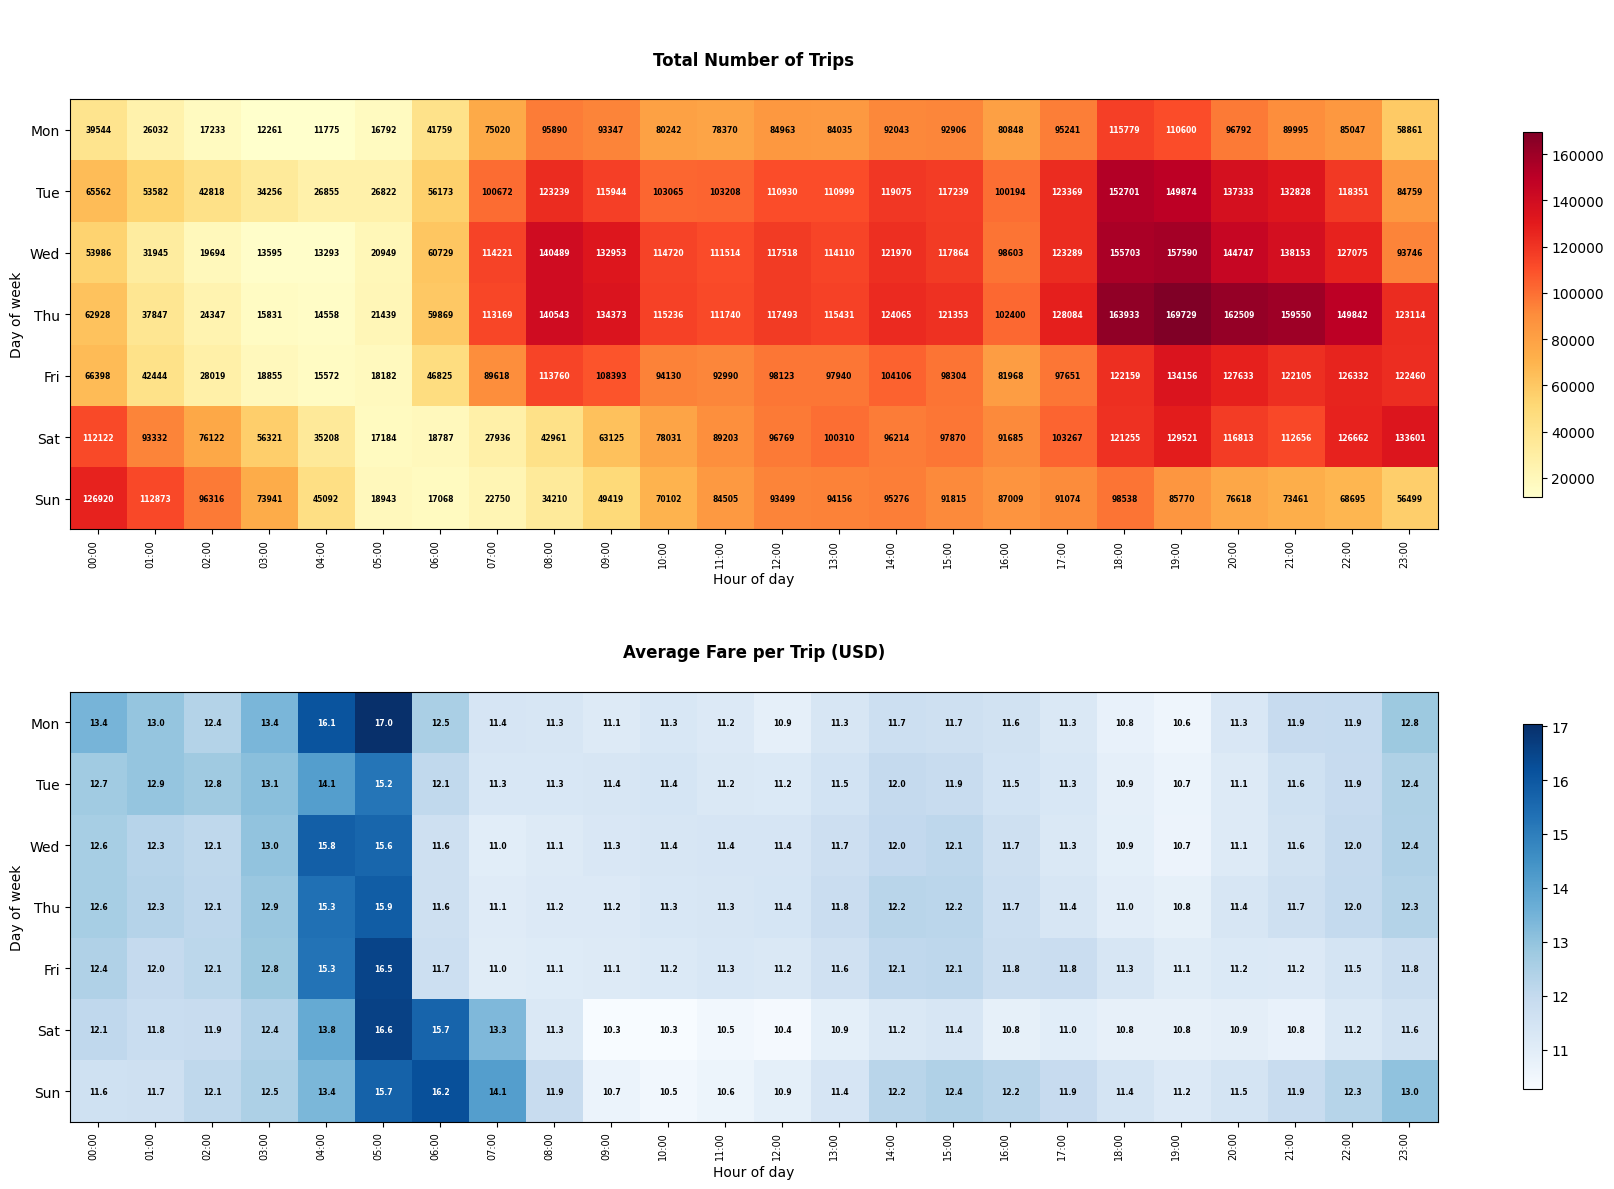

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Convert the Polars frames to NumPy arrays so Matplotlib can draw them directly.
trips_array = matrix_trips.drop("weekday").to_numpy()
fare_array = matrix_fare.drop("weekday").to_numpy()

# Draw the first heatmap for the total number of trips.
im1 = axes[0].imshow(trips_array, cmap="YlOrRd", aspect="auto")
plt.colorbar(im1, ax=axes[0], shrink=0.85)
axes[0].set_title("\n\nTotal Number of Trips\n", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("Hour of day", fontsize=10)
axes[0].set_ylabel("Day of week", fontsize=10)
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(day_labels, fontsize=10)
axes[0].set_xticks(range(24))
axes[0].set_xticklabels(hour_labels, rotation=90, ha="right", fontsize=7)

# Annotate every cell with its value and choose the text color based on brightness.
norm_trips = mcolors.Normalize(vmin=trips_array.min(), vmax=trips_array.max())
colormap_trips = plt.get_cmap("YlOrRd")

for row in range(trips_array.shape[0]):
    for col in range(trips_array.shape[1]):
        val = trips_array[row, col]
        r, g, b, _ = colormap_trips(norm_trips(val))
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "white" if brightness < 0.5 else "black"
        axes[0].text(
            col,
            row,
            format(val, ".0f"),
            ha="center",
            va="center",
            fontsize=5.5,
            color=text_color,
            fontweight="bold",
        )

# Draw the second heatmap for the average fare per trip.
im2 = axes[1].imshow(fare_array, cmap="Blues", aspect="auto")
plt.colorbar(im2, ax=axes[1], shrink=0.85)
axes[1].set_title("\n\nAverage Fare per Trip (USD)\n", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("Hour of day", fontsize=10)
axes[1].set_ylabel("Day of week", fontsize=10)
axes[1].set_yticks(range(7))
axes[1].set_yticklabels(day_labels, fontsize=10)
axes[1].set_xticks(range(24))           
axes[1].set_xticklabels(hour_labels, rotation=90, ha="right", fontsize=7)

# Annotate the fare heatmap with a readable text color for each cell.
norm_fare = mcolors.Normalize(vmin=fare_array.min(), vmax=fare_array.max())
colormap_fare = plt.get_cmap("Blues")

for row in range(fare_array.shape[0]):
    for col in range(fare_array.shape[1]):
        val = fare_array[row, col]
        r, g, b, _ = colormap_fare(norm_fare(val))
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "white" if brightness < 0.5 else "black"
        axes[1].text(
            col,
            row,
            format(val, ".1f"),
            ha="center",
            va="center",
            fontsize=5.5,
            color=text_color,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

#### Getting the top 5 (weekday, hour) slots by average fare

In [27]:
# To find the top 5 (weekday, hour) slots with the highest average fare, I sort the temporal_df
# DataFrame by avg_fare in descending order and take the first 5 rows. 
top5_df = (
    temporal_df
    .sort("avg_fare", descending=True)
    .head(5)
    .with_columns(
        pl.when(pl.col("weekday") == 1).then(pl.lit("Monday"))
        .when(pl.col("weekday") == 2).then(pl.lit("Tuesday"))
        .when(pl.col("weekday") == 3).then(pl.lit("Wednesday"))
        .when(pl.col("weekday") == 4).then(pl.lit("Thursday"))
        .when(pl.col("weekday") == 5).then(pl.lit("Friday"))
        .when(pl.col("weekday") == 6).then(pl.lit("Saturday"))
        .otherwise(pl.lit("Sunday"))
        .alias("day_name")
    )
    # Reorder columns so day_name appears next to the numeric weekday
    .select(["weekday", "day_name", "hour", "avg_fare"])
)
 
print("\nTop 5 (weekday, hour) slots by average fare:")
display(top5_df)


Top 5 (weekday, hour) slots by average fare:


weekday,day_name,hour,avg_fare
i8,str,i8,f64
1,"""Monday""",5,17.037845
6,"""Saturday""",5,16.582082
5,"""Friday""",5,16.492713
7,"""Sunday""",6,16.205944
1,"""Monday""",4,16.106072


### Exercise 7 (12 pts)

Define a *high-value trip* as one satisfying **at least two** of the following conditions:

- `fare_amount` is in the top 10%
- `tip_amount > 50%` of `fare_amount`
- `trip_distance < 2 miles` AND `fare_amount` above the median

Tasks:

1. Extract all high-value trips.
2. Select only the rides longer than 10 miles (in a straight line).
3. Report the total number of such trips.
4. Create a scatterplot:
   - x-axis: `trip_distance`
   - y-axis: `fare_amount`

4. Briefly interpret the observed patterns

### Solution 7

#### Computing the conditions with their thresholds

In [28]:
# Threshold for getting 10% fares_amount, using the 90th quantile of the fare_amount distribution
fare_90th_threshold = df['fare_amount'].quantile(0.90)
# Threshold for getting 50% fares_amount, using the median of the fare_amount distribution
fare_median_threshold = df["fare_amount"].median()
 
print(f"90th-percentile Fare Threshold: ${fare_90th_threshold:.2f}")
print(f"Median Fare Threshold: ${fare_median_threshold:.2f}")

# Defining the three conditions for filtering the trips with the correct thresholds.
cond1 = pl.col("fare_amount") >= fare_90th_threshold
cond2 = pl.col("tip_amount") > pl.col("fare_amount") * 0.5
cond3 = (pl.col("trip_distance") < 2) & (pl.col("fare_amount") > fare_median_threshold)

90th-percentile Fare Threshold: $21.00
Median Fare Threshold: $9.00


#### Creating the high-value trips dataframe and calculating the total number of high-value trips

In [29]:
# Dataframe with the trips that satisfy at least 2 of the 3 conditions, which are considered high-value trips.
df_high_value = (
    df
    .with_columns([
        cond1.cast(pl.Int8).alias("c1"),
        cond2.cast(pl.Int8).alias("c2"),
        cond3.cast(pl.Int8).alias("c3"),
    ])
    .filter((pl.col("c1") + pl.col("c2") + pl.col("c3")) >= 2)
    .drop(["c1", "c2", "c3"])
)

print(f"Total number of high-value trips: {len(df_high_value):,}")

Total number of high-value trips: 20,684


#### Calculating the total number of high-value trips longer than 10 miles

In [30]:
# Filters the high-value trips to keep only those with trip_distance > 10 miles
df_high_value_10 = df_high_value.filter(pl.col("trip_distance") > 10)
print(f"Total number of high-value trips longer than 10 miles: {len(df_high_value_10):,}")

Total number of high-value trips longer than 10 miles: 785


#### Visualization or the Scatter Plot and observation of patterns

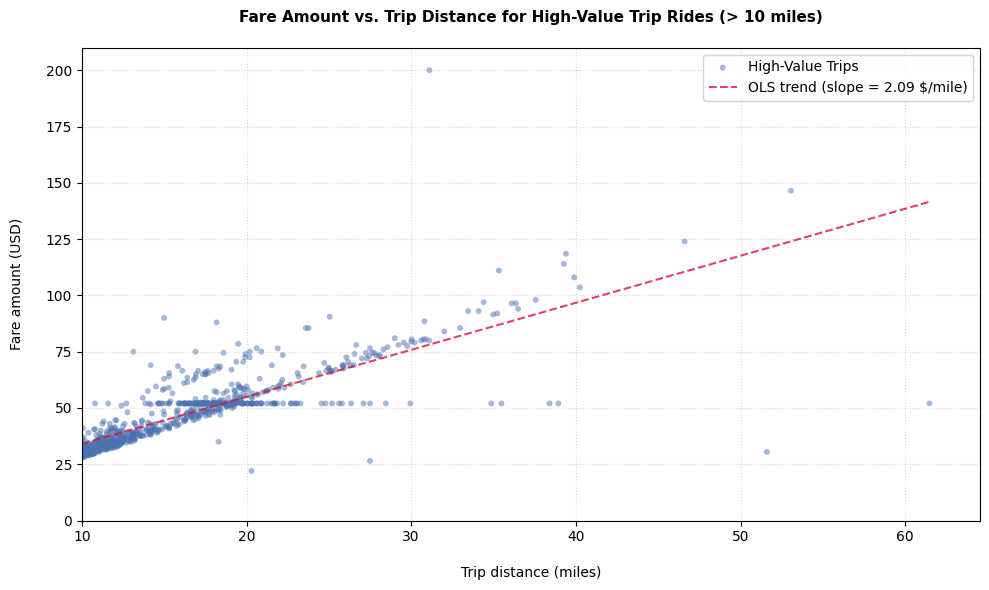

In [31]:
# Computes the minimum, maximum, and average trip distance and fare amount for the high-value
# trips longer than 10 miles.
high_value_stats = df_high_value_10.select([
    pl.col("trip_distance").min().alias("dist_min"),
    pl.col("trip_distance").max().alias("dist_max"),
    pl.col("trip_distance").mean().alias("dist_mean"),
    pl.col("fare_amount").min().alias("fare_min"),
    pl.col("fare_amount").max().alias("fare_max"),
    pl.col("fare_amount").mean().alias("fare_mean"),
])

# Extract values dynamically into variables
dist_min, dist_max, dist_mean, fare_min, fare_max, fare_mean = high_value_stats.row(0)

# Extract numpy arrays for plotting
x = df_high_value_10["trip_distance"].to_numpy()
y = df_high_value_10["fare_amount"].to_numpy()   

# Create the scatter plot chart with Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    x, y,
    c="#4C72B0", alpha=0.5, s=18,
    label="High-Value Trips",
    edgecolors="none",
)

# Ordinary Least Squares (OLS) trend line
coeffs = np.polyfit(x, y, 1)
x_line = np.linspace(dist_min, dist_max, 300)
y_line = np.polyval(coeffs, x_line)

ax.plot(
    x_line, y_line,
    color="crimson", linewidth=1.5, linestyle="--", alpha=0.8,
    label=f"OLS trend (slope = {coeffs[0]:.2f} $/mile)",
)

# Setting limits slightly above the actual maximums found in high_value_stats
xlim_max = dist_max * 1.05  # Adds a 5% buffer to the max distance
ylim_max = fare_max * 1.05  # Adds a 5% buffer to the max fare
ax.set_xlim(10, xlim_max) 
ax.set_ylim(0,  ylim_max)

# Setting labels, title, legend, and grid for better readability
ax.set_xlabel("\nTrip distance (miles)", fontsize=10)
ax.set_ylabel("Fare amount (USD)\n",     fontsize=10)
ax.set_title(
    "Fare Amount vs. Trip Distance for High-Value Trip Rides (> 10 miles)\n",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

##### Observations on the Scatter Plot

The scatterplot illustrates the relationship between trip distance and fare amount for the filtered subset of high-value trips longer than 10 miles. Several distinct patterns can be observed from the visualization:

- **Strong Linear Correlation**: There is a clear, baseline linear relationship between distance and cost, as shown by the Ordinary Least Squares (OLS) trend line with a positive slope of $2.09 per mile. The high density of points along this diagonal represents standard taximeter fares.

- **Flat-Rate Pricing (Horizontal Striping)**: A distinct horizontal cluster appears around the $52-53 mark, spanning from around 15 to nearly 30 miles. This proves the presence of fixed flat-rate fares (such as airport transfers), where the cost is completely decoupled from the actual distance traveled.

- **High-Value and Distance Outliers**: Significant anomalies are visible, including a trip with a distance of a little more than 30/31 miles, reaching the absolute maximum of $200 (well above the trend line), and a few extremely long trips over 50 miles with unusually low fares. These reflect exceptional tipping behavior, negotiated rates, or potential data entry errors.

### Exercise 8 (16 pts)

Analyze driver performance using earnings efficiency:

1. For each trip, compute:
   - trip duration in hours.
   - total earnings = `fare_amount + tip_amount`.

2. Filter:
   - only keep durations between `3 minutes and 5 hours`.

3. For each driver (`hack_license`), compute:
   - total earnings.
   - total driving time (in hours).
   - earnings per hour.
   - total number of trips.

4. Select the **top 15% drivers** based on number of trips.

5. Classify trips into:
   - **day** (i.e., `06:00–18:00`).
   - **night** (remaining hours).

6. Compare driver efficiency:
   - Plot the distribution of earnings per hour for `day vs night drivers` (notice that a driver can be both a "day" and "night" driver in case it performed at least one day ride and one night ride).

7. Answer:
   - Which group appears more efficient?
   - Provide a short explanation based on your results.

### Solution 8

#### Computing the duration and the total earnings for each trip

In [32]:
# Adding duration_hours, which is the trip duration in hours computed as the difference between 
# dropoff_datetime and pickup_datetime (converted to seconds and then to hours), 
# and total_earnings, which is the sum of fare_amount and tip_amount for each trip.
df = df.with_columns([
    (
        (pl.col("dropoff_datetime") - pl.col("pickup_datetime"))
        .dt.total_seconds() / 3600.0
    ).alias("duration_hours"),

    (pl.col("fare_amount") + pl.col("tip_amount"))
        .alias("total_earnings"),
])

print("Dataframe with duration_hours and total_earnings columns:")
display(df.select(["hack_license", "pickup_datetime", "dropoff_datetime", "duration_hours", "total_earnings"]).head(20))

Dataframe with duration_hours and total_earnings columns:


hack_license,pickup_datetime,dropoff_datetime,duration_hours,total_earnings
str,datetime[μs],datetime[μs],f64,f64
"""BA96DE419E711691B9445D6A6307C1…",2013-01-01 15:11:48,2013-01-01 15:18:10,0.106111,6.5
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-06 00:18:35,2013-01-06 00:22:54,0.071944,6.0
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-05 18:49:41,2013-01-05 18:54:23,0.078333,5.5
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:54:15,2013-01-07 23:58:20,0.068056,5.0
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:25:03,2013-01-07 23:34:24,0.155833,9.5
…,…,…,…,…
"""7CE849FEF67514F080AF80D990F7EF…",2013-01-10 14:27:28,2013-01-10 14:45:21,0.298056,16.5
"""351BE7D984BE17DB2FA80A748E8164…",2013-01-07 22:09:59,2013-01-07 22:19:50,0.164167,9.0
"""460C3F57DD9CB2265DB75B14CD7022…",2013-01-07 17:18:16,2013-01-07 17:20:55,0.044167,4.5


#### Filtering trips with duration between 3 minutes and 5 hours

In [33]:
MIN_HOURS = 3.0 / 60.0 # Minimum duration threshold of 3 minutes, converted to hours (3/60 = 0.05 hours)
MAX_HOURS = 5.0 # Maximum duration threshold of 5 hours
 
df_filtered = df.filter(
    (pl.col("duration_hours") >= MIN_HOURS) &
    (pl.col("duration_hours") <= MAX_HOURS)
)

# It is possible to see that in the following output the filtered dataframe will not contain the trip with duration
# equals to 0.044167 which was visible in the previous output and is less than the minimum threshold of 0.05 hours (3 minutes).
print("Dataframe after filtering by trip duration (3 minutes ≤ duration ≤ 5 hours):")
display(df_filtered.select(["hack_license", "pickup_datetime", "dropoff_datetime", "duration_hours", "total_earnings"]).head(20))

Dataframe after filtering by trip duration (3 minutes ≤ duration ≤ 5 hours):


hack_license,pickup_datetime,dropoff_datetime,duration_hours,total_earnings
str,datetime[μs],datetime[μs],f64,f64
"""BA96DE419E711691B9445D6A6307C1…",2013-01-01 15:11:48,2013-01-01 15:18:10,0.106111,6.5
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-06 00:18:35,2013-01-06 00:22:54,0.071944,6.0
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-05 18:49:41,2013-01-05 18:54:23,0.078333,5.5
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:54:15,2013-01-07 23:58:20,0.068056,5.0
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:25:03,2013-01-07 23:34:24,0.155833,9.5
…,…,…,…,…
"""7CE849FEF67514F080AF80D990F7EF…",2013-01-10 14:27:28,2013-01-10 14:45:21,0.298056,16.5
"""351BE7D984BE17DB2FA80A748E8164…",2013-01-07 22:09:59,2013-01-07 22:19:50,0.164167,9.0
"""36773E80775F26CD1158EB5450A61C…",2013-01-07 06:08:51,2013-01-07 06:13:14,0.073056,7.0


#### Computing the drivers' stats and selecting the top 15% by number of trips

In [34]:
# Grouping by hack_license to compute total_earnings, total_hours, and total_trips for each driver, then computing earnings_per_hour 
# and sorting by total_trips in descending order to have the most active drivers at the top of the resulting dataframe for
# better readability.
driver_stats = (
    df_filtered
    .group_by("hack_license")
    .agg([
        pl.col("total_earnings").sum().alias("total_earnings"),
        pl.col("duration_hours").sum().alias("total_hours"),
        pl.len().alias("total_trips"),
    ])
    .with_columns(
        (pl.col("total_earnings") / pl.col("total_hours"))
            .alias("earnings_per_hour")
    )
    .sort("total_trips", descending=True)
)

print("\nDriver stats sample (top 20 by total_trips):")
display(driver_stats.head(20))

# To find the threshold for the top 15% most active drivers by total_trips, I compute the 85th percentile of the total_trips
# distribution using the quantile function with interpolation="lower" to get a conservative threshold that includes all drivers
#  with total_trips equal to or above that value in the top 15%.
trips_85th_threshold = driver_stats["total_trips"].quantile(0.85, interpolation="lower")
print(f"\n85th-percentile Total Trips Threshold: {trips_85th_threshold:.0f}")

# Filtering the drivers with total_trips greater than or equal to the computed threshold to get the top 15% most active drivers,
# and printing the number of drivers in that group.
top15_cond = pl.col("total_trips") >= trips_85th_threshold
top_drivers = driver_stats.filter(top15_cond)
print(f"Number of Drivers in Top 15% by number of trips: {len(top_drivers):,}")


Driver stats sample (top 20 by total_trips):


hack_license,total_earnings,total_hours,total_trips,earnings_per_hour
str,f64,f64,u32,f64
"""F49FD0D84449AE7F72F3BC492CD6C7…",16724.4,262.75,1542,63.65138
"""51C1BE97280A80EBFA8DAD34E1956C…",17366.21,259.4,1535,66.94761
"""847349F8845A667D9AC7CDEDD1C873…",19911.38,297.611389,1438,66.903958
"""22CA618759C716436EA3257480199A…",17033.47,256.25,1438,66.472078
"""3D757E111C78F5CAC83D44A92885D4…",17390.45,281.179722,1428,61.848166
…,…,…,…,…
"""7B3DAEAD0556C7DC4BB925B0A8BED5…",17225.21,260.316667,1290,66.170216
"""2BF7915E6DC6252344DA12975B2B3E…",19031.54,274.572778,1287,69.313281
"""70675A51BA7800862B7AB888998DC9…",15515.93,249.766667,1280,62.1217



85th-percentile Total Trips Threshold: 650
Number of Drivers in Top 15% by number of trips: 4,813


#### Classifications of trips into days and night trips

In [35]:
# Adding time_of_day column to df_filtered, with value "day" if the trip started between 6:00 (inclusive) and 18:00 (exclusive), 
# and "night" otherwise.
df_filtered = df_filtered.with_columns(
    pl.when(
        (pl.col("hour") >= 6) & (pl.col("hour") < 18)
    )
    .then(pl.lit("day"))
    .otherwise(pl.lit("night"))
    .alias("time_of_day")
)

print("Dataframe with time_of_day column added:")
display(df_filtered.select(["hack_license", "pickup_datetime", "dropoff_datetime", "hour", "time_of_day"]).head(20))

Dataframe with time_of_day column added:


hack_license,pickup_datetime,dropoff_datetime,hour,time_of_day
str,datetime[μs],datetime[μs],i8,str
"""BA96DE419E711691B9445D6A6307C1…",2013-01-01 15:11:48,2013-01-01 15:18:10,15,"""day"""
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-06 00:18:35,2013-01-06 00:22:54,0,"""night"""
"""9FD8F69F0804BDB5549F40E9DA1BE4…",2013-01-05 18:49:41,2013-01-05 18:54:23,18,"""night"""
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:54:15,2013-01-07 23:58:20,23,"""night"""
"""51EE87E3205C985EF8431D850C7863…",2013-01-07 23:25:03,2013-01-07 23:34:24,23,"""night"""
…,…,…,…,…
"""7CE849FEF67514F080AF80D990F7EF…",2013-01-10 14:27:28,2013-01-10 14:45:21,14,"""day"""
"""351BE7D984BE17DB2FA80A748E8164…",2013-01-07 22:09:59,2013-01-07 22:19:50,22,"""night"""
"""36773E80775F26CD1158EB5450A61C…",2013-01-07 06:08:51,2013-01-07 06:13:14,6,"""day"""


#### Computing driver stats by **time of day** (Top 15% subset)

In [36]:
# In a similar way to the previous grouping by driver, I can group by both hack_license and time_of_day to compute total_earnings, 
# total_hours, and n_trips for each driver in day and night trips (since a driver may have trips in both time periods), then compute 
# earnings_per_hour for each time of day and sort by hack_license and time_of_day for better readability. This is different from
# the previous grouping by driver because now I have multiple rows for each driver, one for day and one for night (if the driver has 
# trips in both time periods).
driver_stats_time_of_day = (
    df_filtered
    .group_by(["hack_license", "time_of_day"])
    .agg([
        pl.col("total_earnings").sum().alias("total_earnings"),
        pl.col("duration_hours").sum().alias("total_hours"),
        pl.len().alias("n_trips"),
    ])
    .with_columns(
        (pl.col("total_earnings") / pl.col("total_hours"))
            .alias("earnings_per_hour")
    )
)

# print("\nDriver stats by time of day sample (top 20 by total_earnings):")
# display(driver_stats_time_of_day.sort(["hack_license", "time_of_day"]).head(20))

# To get the time of day stats for just the top 15% most active drivers, I can perform a semi-join between 
# driver_stats_time_of_day and top_drivers
top_driver_ids = top_drivers.select("hack_license")

# This dataframe will contain only the rows of driver_stats_time_of_day where hack_license is present in top_driver_ids,
# effectively filtering the stats by time of day to keep only the top 15% most active drivers.
driver_top_time_of_day = driver_stats_time_of_day.join(
    top_driver_ids, 
    on="hack_license", 
    how="semi")

# This dataframe will contain the drivers that have trips in both day and night shifts, since they will have n_groups = 2 
# (two different values of time_of_day).
both_day_and_night = (
    driver_top_time_of_day
    .group_by("hack_license")
    .agg(pl.col("time_of_day").n_unique().alias("n_groups"))
    .filter(pl.col("n_groups") == 2)
)

# Printing the results, if everything is correct the number of drivers active in both day and night shifts should be less than
# or equal to the total number of drivers in the top 15% most active drivers.
print(f"\nRows in driver x time_of_day table (top 15% drivers): "f"{len(driver_top_time_of_day):,}")
print(f"Drivers active in both day and night shifts: {len(both_day_and_night):,}")

display(driver_top_time_of_day.sort(["hack_license", "time_of_day"]).head(20))
display(both_day_and_night.sort("hack_license").head(20))


Rows in driver x time_of_day table (top 15% drivers): 9,350
Drivers active in both day and night shifts: 4,537


hack_license,time_of_day,total_earnings,total_hours,n_trips,earnings_per_hour
str,str,f64,f64,u32,f64
"""001B5364A9CAEC8250250BC05E2869…","""day""",7817.92,122.256389,673,63.946924
"""001B5364A9CAEC8250250BC05E2869…","""night""",36.35,0.448611,4,81.027864
"""0022A86EEFEE75C5224C53AE813397…","""day""",5628.55,92.981111,408,60.534338
"""0022A86EEFEE75C5224C53AE813397…","""night""",3893.57,60.294722,299,64.575635
"""005195D23A99D318120C96A782F67D…","""day""",1151.85,17.810556,103,64.672323
…,…,…,…,…,…
"""00A2DC1380E44036AFD1EA28FA133F…","""night""",4172.85,64.283333,337,64.913404
"""00B7E4E62A1EB052A6543ACC403688…","""day""",8355.51,132.1425,714,63.231057
"""00B7E4E62A1EB052A6543ACC403688…","""night""",194.12,1.831111,7,106.012136


hack_license,n_groups
str,u32
"""001B5364A9CAEC8250250BC05E2869…",2
"""0022A86EEFEE75C5224C53AE813397…",2
"""005195D23A99D318120C96A782F67D…",2
"""005DC767BC7CA7827D0923790CF212…",2
"""006114F940CB87B3ABDCE9BF6DF6FC…",2
…,…
"""00F19A8714CF5D4DF54F881F598ED8…",2
"""00FCDAAE16EBD65BF9A8480A39BA2A…",2
"""0100C603C614DA362BFAFE638D8848…",2


#### Summary of earnings per hour

In [37]:
# Extracting the earnings_per_hour values for day and night shifts into separate arrays for the top 15% most active drivers,
# to be used for summary statistics and comparison between the two time periods.
earning_per_hour_day = driver_top_time_of_day.filter(pl.col("time_of_day") == "day")["earnings_per_hour"]
earning_per_hour_night = driver_top_time_of_day.filter(pl.col("time_of_day") == "night")["earnings_per_hour"]

# To mitigate the influence of outliers in the earnings_per_hour distribution, I apply a cap at the 99th percentile 
# value of the combined distribution of day and night earnings_per_hour. This means that any earnings_per_hour value above
#  that threshold will be set to the threshold value, effectively reducing the impact of extreme values on the summary statistics.
cap = float(
    pl.concat([earning_per_hour_day, earning_per_hour_night]).quantile(0.999)
)
day_arr = earning_per_hour_day.clip(upper_bound=cap).to_numpy()
night_arr = earning_per_hour_night.clip(upper_bound=cap).to_numpy()
 
# Summary statistics
summary = driver_top_time_of_day.group_by("time_of_day").agg([
    pl.col("earnings_per_hour").mean().round(2).alias("mean_earnings_per_hour"),
    pl.col("earnings_per_hour").median().round(2).alias("median_earnings_per_hour"),
    pl.col("earnings_per_hour").std().round(2).alias("std_dev_earnings_per_hour"),
    pl.len().alias("driver_count"),
]).sort("time_of_day")
 
print("\nEarnings-per-hour summary (Top 15% active drivers, capped at 99.9th percentile):")
display(summary)


Earnings-per-hour summary (Top 15% active drivers, capped at 99.9th percentile):


time_of_day,mean_earnings_per_hour,median_earnings_per_hour,std_dev_earnings_per_hour,driver_count
str,f64,f64,f64,u32
"""day""",62.96,62.71,4.14,4805
"""night""",71.89,69.25,10.06,4545


#### Visualizing driver efficiency (Day vs Night) with observations

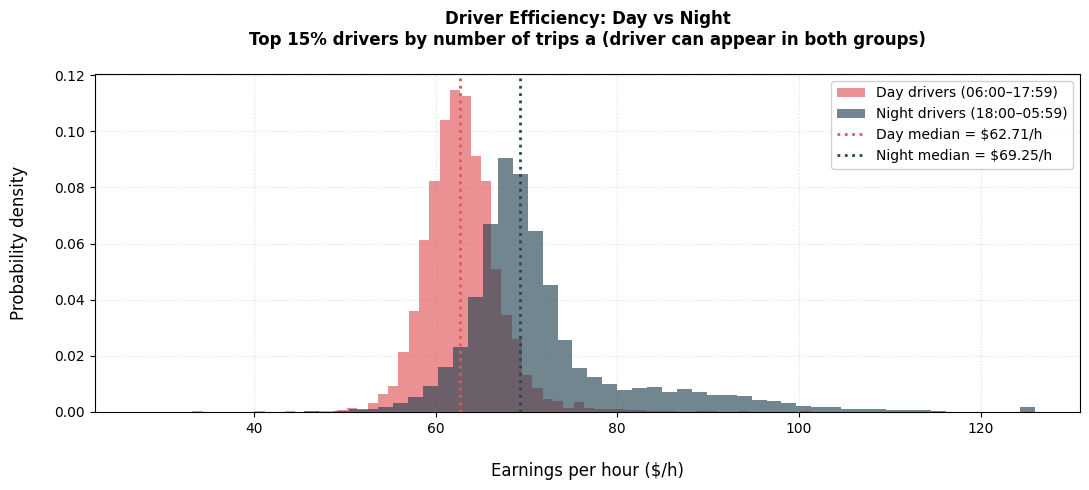

In [38]:
# Defining colors for the histograms and median lines to improve readability and visual
# distinction between day and night drivers. 
DAY_COLOR   = "#E15759"  
NIGHT_COLOR = "#264653"  

# Getting the median lines
day_median = float(np.median(day_arr))
night_median = float(np.median(night_arr))

# Creating the histogram plot with Matplotlib, showing the distribution of earnings_per_hour for day and night drivers,
# with different colors and median lines for better comparison. 
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(day_arr, bins=60, density=True, alpha=0.65,
        color=DAY_COLOR, label="Day drivers (06:00–17:59)", zorder=3)
ax.hist(night_arr, bins=60, density=True, alpha=0.65,
        color=NIGHT_COLOR, label="Night drivers (18:00–05:59)", zorder=3)
 
ax.axvline(day_median,   color=DAY_COLOR,   linewidth=2.0,
           linestyle=":", zorder=4,
           label=f"Day median = ${day_median:.2f}/h")
ax.axvline(night_median, color=NIGHT_COLOR, linewidth=2.0,
           linestyle=":",  zorder=4,
           label=f"Night median = ${night_median:.2f}/h")
 
ax.set_xlabel("\nEarnings per hour ($/h)", fontsize=12)
ax.set_ylabel("Probability density\n", fontsize=12)
ax.set_title(
    "Driver Efficiency: Day vs Night\n"
    "Top 15% drivers by number of trips a (driver can appear in both groups)\n",
    fontsize=12, fontweight="bold",
)


ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.4, zorder=0)
 
plt.tight_layout()
plt.show()


##### Observations on the Efficiency Distribution Plot

Based on the results shown in the distribution plot, the night-shift group demonstrates a higher efficiency compared to the day-shift group. Several key visual and statistical patterns can be observed from the visualization:

- **Higher Central Tendency**: The median earnings per hour for night drivers (calculated in the previous cell and equals to $69.25/h) is notably higher than that of day drivers ($62.71/h). This represents a clear shift of the entire core distribution toward the right, indicating that a typical driver earns more when working during the night.

- **Right-Skewed Distribution**: While the day-shift distribution is highly concentrated and drops off sharply after $75/h, the night-shift distribution features a much thicker, heavier right tail that extends well beyond $100/h. This implies that night drivers have a significantly higher probability of experiencing exceptionally high-earning hours.

- **Traffic and Pricing Dynamics**: This disparity in efficiency can likely be attributed to urban traffic patterns and surcharge structures. Night-time operations benefit from reduced road congestion—allowing drivers to complete more trips in less time—combined with potentially higher base rates, midnight premiums, or more generous tipping behavior associated with nightlife venues and late-night airport transfers.